In [129]:
#from google.colab import drive
#drive.mount('/content/drive')

In [130]:
import sys
sys.path.append(r"C:\Users\Michael Ocampo\Documents\P_Files\opensees\final_\functions")
#sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")

In [131]:
#!sudo apt update
#!sudo apt install libglu1-mesa libglu1-mesa-dev
#!pip install -r requirements.txt

In [132]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import time as tt
import gmsh
import solver_function as SF
import materialParam as param
import RCs_section as RCS
import importlib
importlib.reload(SF)
importlib.reload(param)
importlib.reload(RCS)
from solver_function import *
from materialParam import *
from RCs_section import *

In [133]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (150173433632)>


In [134]:
#
# Test Parameters − Consolidation Stage
#
vConf = -187  # Vertical confining pressure
hConf = -90  # Horizontal confining pressure
#
# Test Parameters − Shearing Stage
#
devDisp = -0.1  # Imposed vertical displacement
#
# Material parameters
#
rhoS = 1.8  # Saturated soil mass density
Gr = 1e5  # Reference Shear modulus
Kr = 1.7e5  # Reference Bulk modulus
phi = 35.5  # Peak friction angle
gamax = 0.085  # Peak shear strain
pr = 100  # Reference mean effective pressure
D = 0.5  # Pressure dependence coefficient
PT = 31  # Phase Trasformation angle
c1 = 0.125  # Const for contraction
c3 = 1  # Const for contraction
d1 = 0.25  # Const for dilation
d3 = 5.7  # Const for dilation
NYS = 30  # Number of Yield Surfaces
c2 = 0.5  # Const for contraction
d2 = 3.9  # Const for dilation
l1 = 1.95  # Damage Parameter
l2 = 0  # Damage Parameter
Bf = 2.2e6  # Fluid bulk modulus
e = 0.9  # Soil void ratio
n = e / (1 + e)  # Soil porosity
Bc = Bf / n  # Combined bulk modulus
perm = 1e-16  # Perm. −undrained response−
#
# Rayleigh damping parameters
#
damp = 0.1
omega1 = 0.0157
omega2 = 64.123
a1 = 2.0 * damp / (omega1 + omega2)
a0 = a1 * omega1 * omega2
#
#
import openseespy.opensees as ops
import time
#
ops.wipe()
#
ops.model('BasicBuilder', '-ndm', 3, '-ndf', 4)
#
# Material Definition
#
ops.nDMaterial('PressureDependMultiYield02', 1, 3, rhoS, Gr, Kr, phi,
               gamax, pr, D, PT, c1, c3, d1, d3, NYS, c2, d2, l1, l2, e)
#
# Nodes Definition
#
ops.node(1, 1.0, 0.0, 0.0)
ops.node(2, 1.0, 1.0, 0.0)
ops.node(3, 0.0, 1.0, 0.0)
ops.node(4, 0.0, 0.0, 0.0)
ops.node(5, 1.0, 0.0, 1.0)
ops.node(6, 1.0, 1.0, 1.0)
ops.node(7, 0.0, 1.0, 1.0)
ops.node(8, 0.0, 0.0, 1.0)
#
# Fixities Definition
#
ops.fix(1, 0, 1, 1, 1)
ops.fix(2, 0, 0, 1, 1)
ops.fix(3, 1, 0, 1, 1)
ops.fix(4, 1, 1, 1, 1)
ops.fix(5, 0, 1, 0, 1)
ops.fix(6, 0, 0, 0, 1)
ops.fix(7, 1, 0, 0, 1)
ops.fix(8, 1, 1, 0, 1)
#
# Finite Element creation
#
ops.element('SSPbrickUP', 1, 1, 2, 3, 4, 5, 6, 7, 8, 1, Bc, 1, perm, perm, perm, e, 1.5e-9)
#
# Output definition
#

ops.recorder('Node', '-file', 'disp1_man.out', '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8,'-dof', 1, 'disp')
ops.recorder('Node', '-file', 'disp2_man.out', '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8,'-dof', 2, 'disp')
ops.recorder('Node', '-file', 'pressure_man.out', '-time', '-node', 8, '-dof', 3, 'vel')
ops.recorder('Element', '-file', 'stress_man.out', '-time', '-ele', 1, 'stress')  # s11 s22 s33 s12 eta (EFFECTIVE stresses)
ops.recorder('Element', '-file', 'strain_man.out', '-time', '-ele', 1, 'strain')  # e11 e22 gama12 (it is not e33 nor e12)
ops.recorder('Element', '-file', 'backbone_man.out', '-ele', 1, 'backbone', 100, 1600)
#
# Define analysis parameters
#
ops.constraints('Penalty', 1e18, 1e18)
ops.test('NormDispIncr', 1e-4, 50, 2)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.integrator('Newmark', 0.5, 0.25)
ops.rayleigh(a0, 0, a1, 0)
ops.analysis('Transient')
#
startT = time.time()
#
#======================================================#
# Stage 1 − Consolidation Procedure #
#======================================================#
vNode = vConf / 4.0
hNode = hConf / 4.0
#
ops.timeSeries('Series', 1, '-time', 0, 500, 10000, '-values', 0, 1, 1)
ops.pattern('Plain', 1, 1)
ops.load(1, hNode, 0, 0, 0)
ops.load(2, hNode, hNode, 0, 0)
ops.load(3, 0, hNode, 0, 0)
ops.load(4, 0, 0, 0, 0)
ops.load(5, hNode, 0, vNode, 0)
ops.load(6, hNode, hNode, vNode, 0)
ops.load(7, 0, hNode, vNode, 0)
ops.load(8, 0, 0, vNode, 0)
#
ops.analyze(500, 1.0)
print('')
print('Consolidation procedure − done.')
print('')
#
# Let the model rest and waves damp out
#
ops.analyze(50, 1.0)
#
#======================================================#
# Stage 2 − Deviatoric Strain #
#======================================================#
#
# Drainage closure
#
for x in range(1, 9):
    ops.remove('sp', x, 4)
#
ops.analyze(50, 1.0)
#
# Keep consolidation pressure applied and set analysis time
#
ops.loadConst('-time', 600.0)
#
# Switch the material to plastic
#
ops.updateMaterialStage('-material', 1, '-stage', 1)
#
# Define loading parameter
#
vDisp = ops.nodeDisp(5, 3)
lvalues = [1, 1 + devDisp / vDisp, 1 + devDisp / vDisp]
#
ops.timeSeries('Series', 3, '-time', 600, 300600, 1000000, '-values', *lvalues, '-factor', 1.0)
ops.pattern('Plain', 3, 3)
ops.sp(5, 3, vDisp)
ops.sp(6, 3, vDisp)
ops.sp(7, 3, vDisp)
ops.sp(8, 3, vDisp)
#
ops.analyze(3000, 100.0)
#
endT = time.time()
print('')
print('Horizontal Shear − done.')
print(f'Execution time: {endT - startT} seconds.')
print('')
#
ops.wipe()


Consolidation procedure − done.



CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28158e-06 (max: 0.0001, Norm deltaR: 9.56461e-17)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30997e-06 (max: 0.0001, Norm deltaR: 7.34344e-17)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28182e-06 (max: 0.0001, Norm deltaR: 4.13549e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30973e-06 (max: 0.0001, Norm deltaR: 7.49914e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28206e-06 (max: 0.0001, Norm deltaR: 4.34443e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30949e-06 (max: 0.0001, Norm deltaR: 5.11788e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28229e-06 (max: 0.0001, Norm deltaR: 6.56817e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30926e-06 (max: 0.0001, Norm deltaR: 1.27796e-15)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28253e-06 (max: 0.0001, Norm deltaR: 7.21645e-16)
CTestNormDispIncr::test() - iteration


Horizontal Shear − done.
Execution time: 1.0162267684936523 seconds.



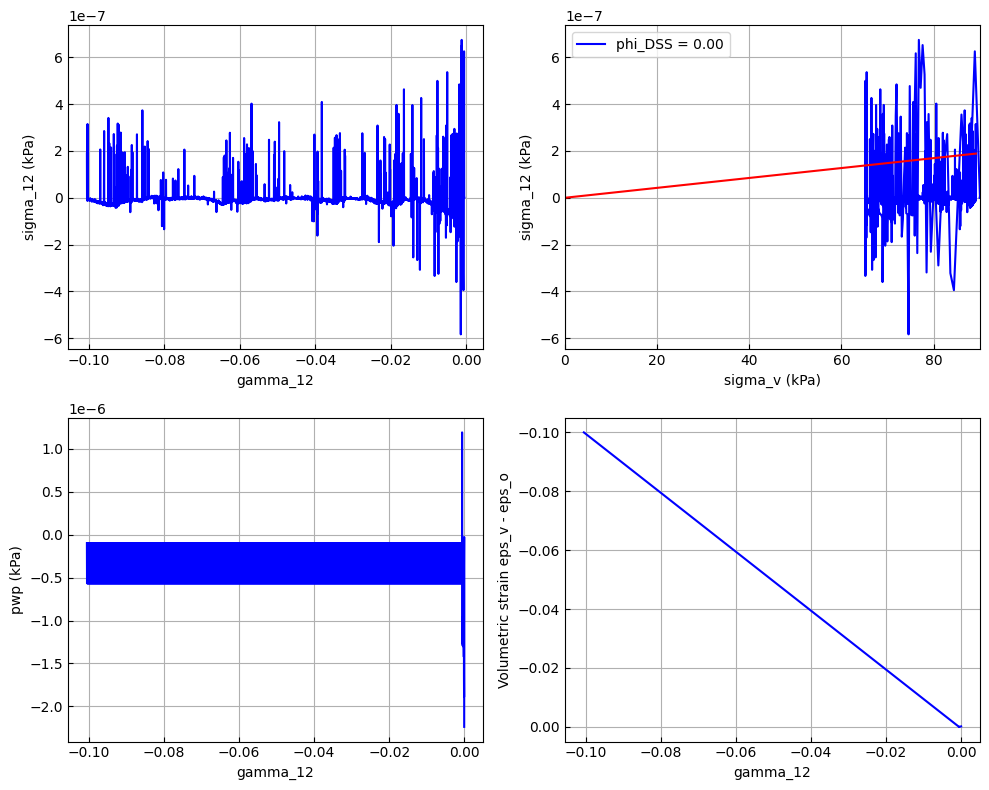

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
del min
# -----------------------------------------------------------------------------
# Post-processor converted and cleaned from MATLAB
# - Safe indexing (MATLAB->Python 1-based -> 0-based)
# - Avoids shadowing builtins (uses np.minimum/np.maximum)
# - Robust file loading with clear errors
# - Defensive index checks and fallbacks
# - Handles all four analysis cases
# -----------------------------------------------------------------------------

# -------------------------- Configuration ------------------------------------
# Options: 'undrained_cyclic', 'undrained_monotonic', 'drained_cyclic', 'drained_monotonic'
Analysis_case = 'undrained_monotonic'
input_dir = Path('output')
consol_step = 500  # as in the MATLAB code (1-based). We'll compute 0-based index below.

# -------------------------- Helpers ------------------------------------------

def load_txt(path: Path) -> np.ndarray:
    """Load whitespace-delimited text file with numpy; give clear message on failure."""
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return np.loadtxt(path)


def safe_idx(arr: np.ndarray, idx: int, fallback: int = 0) -> int:
    """Return idx if in bounds else a fallback index (clamped)."""
    if idx < 0:
        return 0
    if idx >= arr.shape[0]:
        return arr.shape[0] - 1
    return idx

def idx_clamped(i: int, arr: np.ndarray) -> int:
    return int(np.clip(i, 0, arr.shape[0] - 1))

# -------------------------- Load data ---------------------------------------
try:
    input_disp1 = load_txt(input_dir / f'disp1_man.out')
    input_disp2 = load_txt(input_dir / f'disp2_man.out')
    input_stress = load_txt(input_dir / f'stress_man.out')
    input_strain = load_txt(input_dir / f'strain_man.out')
    input_pwp = load_txt(input_dir / f'pressure_man.out')
    input_backbone = load_txt(input_dir / f'backbone_man.out')
except Exception as e:
    print('Error loading files:', e)
    sys.exit(1)

# -------------------------- Preprocessing -----------------------------------
# Convert MATLAB 1-based consol_step to Python 0-based index
consol_i = consol_step - 1

# Displacements
Disp_1 = input_disp1[:, 1:]
Disp_2 = input_disp2[:, 1:]

# Stresses (compression:+, tension:-)
# NOTE: MATLAB used columns 2..6; numpy is 0-based -> columns 1..5
s_11 = -input_stress[:, 1]
s_22 = -input_stress[:, 2]
s_33 = -input_stress[:, 3]
s_12 = input_stress[:, 4]
# eta = input_stress[:, 5] if present
eta = input_stress[:, 5] if input_stress.shape[1] > 5 else None

# Octahedral shear stress
tau_oct = (1.0 / 3.0) * np.sqrt((s_11 - s_22) ** 2 + (s_11 - s_33) ** 2 + (s_22 - s_33) ** 2 + 6.0 * s_12 ** 2)
q = 3.0 / np.sqrt(2.0) * tau_oct

# PWP and mean stress
# Handle the case where the pwp file has fewer than 5 columns
pwp_values = []
if input_pwp.shape[1] >= 2:
    pwp_values.append(input_pwp[:, 1])
if input_pwp.shape[1] >= 3:
    pwp_values.append(input_pwp[:, 2])
if input_pwp.shape[1] >= 4:
    pwp_values.append(input_pwp[:, 3])
if input_pwp.shape[1] >= 5:
    pwp_values.append(input_pwp[:, 4])

# Calculate the average pore water pressure
if pwp_values:
    pwp = np.mean(pwp_values, axis=0)
else:
    # Handle the case where no pwp data is available
    pwp = np.zeros_like(s_11)

p = (s_11 + s_22 + s_33) / 3.0
p_tot = p + pwp
time = input_pwp[:, 0]

# Strains
# input_strain assumed to have columns [time, e11, e22, gamma12, ...]
e_11 = -input_strain[:, 1]
e_22 = -input_strain[:, 2]
gama_12 = input_strain[:, 3]
e_33 = np.zeros_like(e_11)
e_v = e_11 + e_22 + e_33
gama_oct = (2.0 / 3.0) * np.sqrt((e_11 - e_22) ** 2 + (e_22 - e_33) ** 2 + (e_11 - e_33) ** 2 + 6.0 * (gama_12 / 2.0) ** 2)

# CSL and void ratio
cs1, cs2, cs3 = 0.9, 0.1, 1.0
void_i = 0.8
void = void_i - e_22 * (1.0 + void_i)

# counts
total_step = gama_12.shape[0]

# Ru computations (safe denominators)
ru_1 = pwp / np.maximum(p, 0.001)
ru_2 = pwp / p[safe_idx(p, consol_i)]
ru_3 = pwp / s_22[safe_idx(s_22, consol_i)]

# -------------------------- Utility safe indexing for time-series ----------
def idx_clamped(i: int, arr: np.ndarray) -> int:
    return max(0, min(i, arr.shape[0] - 1))

# small helper to fetch value with fallback

def val_at(arr: np.ndarray, i: int, fallback_i: int = None):
    if fallback_i is None:
        fallback_i = arr.shape[0] - 1
    ii = idx_clamped(i, arr)
    return arr[ii]

# -------------------------- Analysis cases ----------------------------------

if Analysis_case == 'drained_cyclic':
    period = 10.0
    cycle = time / period

    NoStepsCycle = 2000
    NoCycleEach = 2

    # MATLAB: corr_steps = [consol_step+NoStepsCycle/4:NoStepsCycle*NoCycleEach:consol_step+9*NoStepsCycle*NoCycleEach]
    start = consol_i + NoStepsCycle // 4
    end = consol_i + 9 * NoStepsCycle * NoCycleEach
    step = NoStepsCycle * NoCycleEach
    corr_steps = np.arange(start, end + 1, step, dtype=int)
    corr_steps = corr_steps[corr_steps < total_step]

    # Secant stiffness
    # Use safe indices; prefer consol_i+1 as MATLAB used consol_step+1 for Gmax
    gmax_idx = idx_clamped(consol_i + 1, gama_12)
    G_sec = s_12[corr_steps] / np.maximum(gama_12[corr_steps], 1e-18)
    G_max = s_12[gmax_idx] / np.maximum(gama_12[gmax_idx], 1e-18)
    G_max_oct = tau_oct[gmax_idx] / np.maximum(gama_oct[gmax_idx], 1e-18)

    # EPRI reference
    GratioEPRI6 = np.array([1, 0.98, 0.919, 0.751, 0.519, 0.271, 0.121, 0.045, 0.024])
    GratioEPRI76 = np.array([1, 0.999, 0.982, 0.9, 0.752, 0.502, 0.282, 0.124, 0.07])
    gama_EPRI = np.array([0.000003, 0.00001, 0.00003, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03])

    # compute gama_EPRI_oct using the strain values at consol_i (MATLAB used index 500)
    idx_500 = idx_clamped(consol_i, e_11)
    gama_EPRI_oct = (2.0 / 3.0) * np.sqrt((e_11[idx_500] - e_22[idx_500]) ** 2 + (e_22[idx_500] - e_33[idx_500]) ** 2 + (e_11[idx_500] - e_33[idx_500]) ** 2 + 6.0 * (gama_EPRI / 2.0) ** 2)

    # Xi (damping ratio) computed by numerical trapezoid over strain vs stress for each cycle window
    Xi = np.zeros_like(corr_steps, dtype=float)
    for k, start_idx in enumerate(corr_steps):
        end_idx = start_idx + NoStepsCycle
        # clamp
        s_idx = idx_clamped(start_idx, s_12)
        e_idx = idx_clamped(end_idx, s_12)
        # make sure slice non-empty
        if e_idx <= s_idx:
            Xi[k] = 0.0
            continue
        hysteresis = np.trapz(s_12[s_idx:e_idx + 1], gama_12[s_idx:e_idx + 1])
        triangle = 0.5 * gama_12[s_idx] * s_12[s_idx]
        if triangle != 0.0:
            Xi[k] = hysteresis / (4.0 * np.pi * triangle) * 100.0
        else:
            Xi[k] = 0.0

    XiEPRI6 = np.array([0.791, 1.27, 2.28, 4.26, 7.75, 14.74, 22.03, 27.12, 30.21])
    XiEPRI76 = np.array([0.591, 0.88, 1.271, 2.46, 4.551, 8.34, 14.13, 21.22, 25.31])

    # Plots
    plt.figure()
    if corr_steps.size > 0:
        plt.semilogx(gama_12[corr_steps], G_sec / G_max, '-ob', linewidth=2, label="PDMY03 - sigma_vo=100 KPa")
    plt.semilogx(gama_EPRI, GratioEPRI6, '--r', linewidth=2, label='EPRI1993 0-6m')
    plt.semilogx(gama_EPRI, GratioEPRI76, '--r', linewidth=2, label='EPRI1993 36-76m')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('G_sec/G_max')
    plt.legend()
    plt.title('G/Gmax vs. Shear Strain')

    plt.figure()
    if corr_steps.size > 0:
        plt.semilogx(gama_12[corr_steps], Xi, '-ob', linewidth=2, label='PDMY03 - sigma_vo=100 KPa')
    plt.semilogx(gama_EPRI, XiEPRI6, '--r', linewidth=2, label='EPRI1993 0-6m')
    plt.semilogx(gama_EPRI, XiEPRI76, '--r', linewidth=2, label='EPRI1993 36-76m')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('Equivalent damping ratio (%)')
    plt.legend()
    plt.title('Damping Ratio vs. Shear Strain')

    plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(gama_12, s_12 / val_at(s_22, consol_i))
    plt.xlabel('gamma_12')
    plt.ylabel('CSR = (sigma_12/sigma_vc)')
    plt.title(f"sigma_vc = {val_at(s_22, consol_i):.2f} kPa")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(cycle[consol_i:], gama_12[consol_i:])
    plt.xlabel('No. of cycles')
    plt.ylabel('gamma_12')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
elif Analysis_case == 'undrained_cyclic':
    period = 1.0
    cycle = time / period

    # use the consol strain as baseline (MATLAB used index consol_step)
    base_idx = idx_clamped(consol_i, gama_12)
    gama_consol = gama_12[base_idx]

    # Find first indices where thresholds are exceeded
    T_1_candidates = np.where(np.abs(gama_12 - gama_consol) > 0.01)[0]
    T_1 = int(T_1_candidates[0]) if T_1_candidates.size > 0 else base_idx
    N_1 = cycle[T_1]

    T_3_candidates = np.where(np.abs(gama_12 - gama_consol) > 0.03)[0]
    T_3 = int(T_3_candidates[0]) if T_3_candidates.size > 0 else base_idx
    N_3 = cycle[T_3]

    T_r_candidates = np.where(ru_3 > 0.98)[0]
    T_r = int(T_r_candidates[0]) if T_r_candidates.size > 0 else base_idx
    N_r = cycle[T_r]

    print(f'N_1 = {N_1}')
    print(f'N_3 = {N_3}')
    print(f'N_r = {N_r}')

    # Plotting
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    plt.plot(gama_12, s_12 / val_at(s_22, consol_i), 'b')
    plt.plot(gama_12[T_1], s_12[T_1] / val_at(s_22, consol_i), 'g.', markersize=12)
    plt.plot(gama_12[T_3], s_12[T_3] / val_at(s_22, consol_i), 'r.', markersize=12)
    plt.plot(gama_12[T_r], s_12[T_r] / val_at(s_22, consol_i), 'm.', markersize=12)
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('CSR = (sigma_12/sigma_vc)')
    plt.title(f"CSR = {np.max(np.abs(s_12)) / val_at(s_22, consol_i):.2f} and sigma_vc = {val_at(s_22, consol_i):.2f} kPa")

    plt.subplot(2, 2, 2)
    ratio_s22 = s_22 / val_at(s_22, consol_i)
    plt.plot(ratio_s22, s_12 / val_at(s_22, consol_i), 'b')
    plt.plot(ratio_s22[T_1], s_12[T_1] / val_at(s_22, consol_i), 'g.', markersize=12)
    plt.plot(ratio_s22[T_3], s_12[T_3] / val_at(s_22, consol_i), 'r.', markersize=12)
    plt.plot(ratio_s22[T_r], s_12[T_r] / val_at(s_22, consol_i), 'm.', markersize=12)
    plt.grid(True)
    plt.xlabel('vertical effective stress ratio (sigma_v/sigma_vc)')
    plt.ylabel('CSR = (sigma_12/sigma_vc)')
    left = np.minimum(0.0, np.min(ratio_s22))
    right = np.max(ratio_s22)
    plt.xlim([left, right])
    plt.title(f"CSR = {np.max(np.abs(s_12)) / val_at(s_22, consol_i):.2f} and sigma_vc = {val_at(s_22, consol_i):.2f} kPa")

    plt.subplot(2, 2, 3)
    plt.plot(cycle[consol_i:], pwp[consol_i:], 'b')
    plt.plot(cycle[T_1], pwp[T_1], 'g.', markersize=12)
    plt.plot(cycle[T_3], pwp[T_3], 'r.', markersize=12)
    plt.plot(cycle[T_r], pwp[T_r], 'm.', markersize=12)
    plt.grid(True)
    plt.ylabel('PWP (kPa)')
    plt.xlabel('No. of cycles')
    plt.ylim([-10, 100])

    plt.subplot(2, 2, 4)
    plt.plot(cycle[consol_i:], gama_12[consol_i:], 'b')
    plt.grid(True)
    plt.xlabel('No. of cycles')
    plt.ylabel('gamma_12')

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
elif Analysis_case == 'drained_monotonic':
    G_max = val_at(s_12, consol_i) / np.maximum(val_at(gama_12, consol_i), 1e-18)
    G_max_oct = val_at(tau_oct, consol_i) / np.maximum(val_at(gama_oct, consol_i), 1e-18)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(gama_12[consol_i:], s_12[consol_i:], 'b', label='sigma_12 vs gamma_12')
    plt.plot(gama_oct[consol_i:], tau_oct[consol_i:], 'r', label='tau_oct vs gamma_oct')
    plt.grid(True)
    plt.xlabel('gamma_12 and gamma_oct')
    plt.ylabel('sigma_12 and tau_oct')
    plt.ylim([0, 60])
    plt.title(f"sigma_vc (kPa) = {val_at(s_22, consol_i):.2f}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(p[consol_i:], tau_oct[consol_i:], 'r')
    plt.plot(s_22[consol_i:], s_12[consol_i:], 'b')
    plt.grid(True)
    plt.ylim([0, 60])

    # calculate slopes and phi safely
    if np.abs(p[-1]) > 1e-18:
        slope_oct = tau_oct[-1] / p[-1]
        # guard arcsin domain
        arg = 3.0 * slope_oct / (2.0 * np.sqrt(2.0) + slope_oct)
        arg_clamped = np.clip(arg, -1.0, 1.0)
        Phi_oct_back_calculated = np.degrees(np.arcsin(arg_clamped))
    else:
        slope_oct = 0.0
        Phi_oct_back_calculated = 0.0

    if np.abs(s_22[-1]) > 1e-18:
        slope_conventional = s_12[-1] / s_22[-1]
        Phi_conventional_back_calculated = np.degrees(np.arctan(slope_conventional))
    else:
        slope_conventional = 0.0
        Phi_conventional_back_calculated = 0.0

    plt.plot([0, np.max(p) * 1.2], [0, (np.max(p) * 1.2) * slope_oct], '--r', label=f'phi_oct = {Phi_oct_back_calculated:.2f}')
    plt.plot([0, np.max(s_22) * 1.2], [0, (np.max(s_22) * 1.2) * slope_conventional], '--b', label=f'phi_DSS = {Phi_conventional_back_calculated:.2f}')
    plt.xlabel("sigma_v and p (kPa)")
    plt.ylabel('sigma_12 and tau_oct')
    plt.xlim([0, np.max(p) * 1.2])
    plt.legend()

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
elif Analysis_case == 'undrained_monotonic':
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    plt.plot(gama_12[consol_i:], s_12[consol_i:], 'b')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('sigma_12 (kPa)')

    plt.subplot(2, 2, 2)
    plt.plot(s_22[consol_i:], s_12[consol_i:], 'b')
    plt.grid(True)
    plt.xlim([0, np.max(s_22)])
    plt.plot([0, s_22[-1]], [0, s_12[-1]], 'r')
    plt.xlabel('sigma_v (kPa)')
    plt.ylabel('sigma_12 (kPa)')

    if np.abs(s_22[-1]) > 1e-18:
        slope_conventional = s_12[-1] / s_22[-1]
        Phi_conventional_back_calculated = np.degrees(np.arctan(slope_conventional))
    else:
        slope_conventional = 0.0
        Phi_conventional_back_calculated = 0.0

    plt.legend([f'phi_DSS = {Phi_conventional_back_calculated:.2f}'])

    plt.subplot(2, 2, 3)
    plt.plot(gama_12, pwp, 'b')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('pwp (kPa)')

    plt.subplot(2, 2, 4)
    plt.plot(gama_12, e_v - e_v[consol_i], 'b')
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.xlabel('gamma_12')
    plt.ylabel('Volumetric strain eps_v - eps_o')

    plt.tight_layout()
    plt.show()

else:
    raise ValueError(f'Unknown Analysis_case: {Analysis_case}')
